# Taller Unidad 3: Regresion Lineal con Credit Risk Data

**Curso:** Analitica Predictiva y Machine Learning  
**Profesor:** Ricardo Ruiz Cortés

---

En esta actividad vas a recorrer el flujo completo de un proyecto de prediccion:  
1. Cargar datos desde una URL publica  
2. Explorar y visualizar  
3. Construir una regresion simple y graficar la recta  
4. Construir una regresion multiple  
5. **Tu turno:** elegir las variables para predecir un nuevo cliente  

> Las celdas marcadas con **TU TURNO** requieren que completes el codigo.

---
## Paso 1: Importar Librerias

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')
plt.rcParams['figure.figsize'] = (10, 6)

print('Librerias cargadas correctamente!')

Librerias cargadas correctamente!


---
## Paso 2: Cargar los Datos desde URL

In [ ]:
url = 'https://raw.githubusercontent.com/ricardoruiz19/courses/main/credit_risk_data.csv'
df = pd.read_csv(url)

print(f'Dimensiones: {df.shape[0]:,} filas x {df.shape[1]} columnas')
df.head()

Dimensiones: 10,000 filas x 10 columnas


,id_cliente,nombre,apellido,edad,antiguedad_laboral,ingresos_anuales,puntaje_credito,monto_prestamo,proposito_prestamo,estado_pago
0,10001,Paola,Vargas,42,8,34941431,438,17017931,Vivienda,Pagado
1,10002,Natalia,Bermúdez,36,6,30216617,472,15824222,Personal,Pagado
2,10003,Héctor,Gutiérrez,44,9,30117400,517,16192617,Negocio,Pagado
3,10004,Miguel,Torres,53,16,45897921,588,12908852,Educacion,Pagado
4,10005,María,Flores,35,10,22349586,580,9540818,Coche,Pagado


---
## Paso 3: Conocer los Datos

In [ ]:
df.describe()

,id_cliente,edad,antiguedad_laboral,ingresos_anuales,puntaje_credito,monto_prestamo
count,10000.00000,10000.000000,10000.000000,1.000000e+04,10000.00000,1.000000e+04
mean,15000.50000,37.728800,8.057500,3.060350e+07,533.71030,1.389531e+07
std,2886.89568,9.467387,5.324963,9.147290e+06,61.46043,6.354691e+06
min,10001.00000,22.000000,0.000000,8.000000e+06,300.00000,1.000000e+06
25%,12500.75000,31.000000,4.000000,2.397119e+07,492.00000,9.140456e+06
50%,15000.50000,37.000000,8.000000,3.039052e+07,534.00000,1.316170e+07
75%,17500.25000,44.000000,12.000000,3.691911e+07,576.00000,1.801846e+07
max,20000.00000,65.000000,27.000000,6.439595e+07,753.00000,4.232373e+07


---
## Paso 4: Limpieza

In [ ]:
df = df.dropna()
print(f'Filas despues de limpieza: {len(df):,}')

Filas despues de limpieza: 10,000


---
## Paso 5: Visualizacion

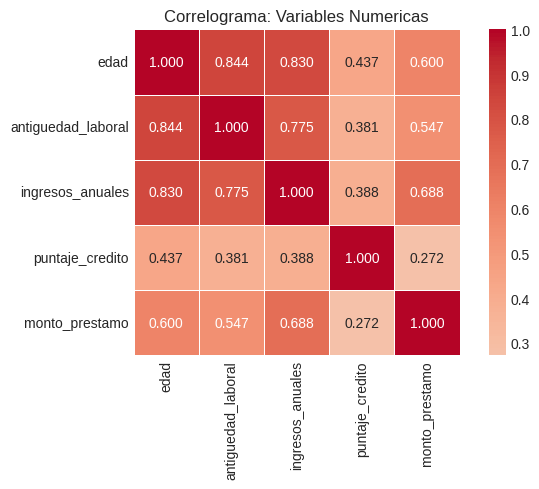

In [ ]:
# Correlograma
cols_num = ['edad', 'antiguedad_laboral', 'ingresos_anuales', 'puntaje_credito', 'monto_prestamo']
plt.figure(figsize=(7, 5))
sns.heatmap(df[cols_num].corr(), annot=True, fmt='.3f', cmap='coolwarm',
            center=0, square=True, linewidths=0.5)
plt.title('Correlograma: Variables Numericas')
plt.tight_layout()
plt.show()

/tmp/ipykernel_35771/3083480125.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='estado_pago', y=col, ax=axes[i],
/tmp/ipykernel_35771/3083480125.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='estado_pago', y=col, ax=axes[i],
/tmp/ipykernel_35771/3083480125.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='estado_pago', y=col, ax=axes[i],


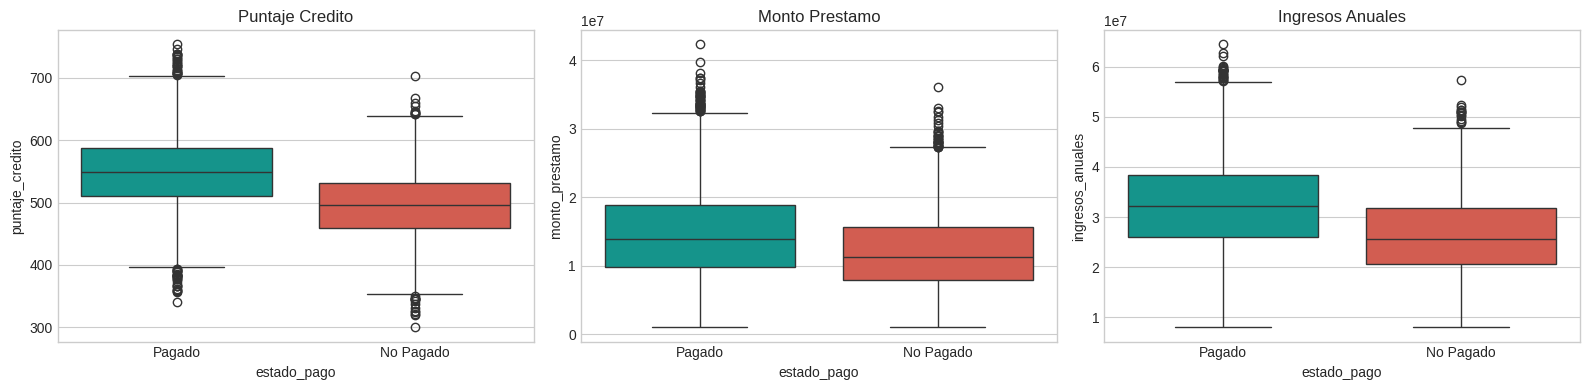

In [ ]:
# Boxplots por estado de pago
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for i, col in enumerate(['puntaje_credito', 'monto_prestamo', 'ingresos_anuales']):
    sns.boxplot(data=df, x='estado_pago', y=col, ax=axes[i],
                palette={'Pagado': '#00A99D', 'No Pagado': '#e74c3c'})
    axes[i].set_title(col.replace('_', ' ').title())
plt.tight_layout()
plt.show()

---
## Paso 6: Train / Test Split

In [ ]:
X = df[['ingresos_anuales']]
y = df['monto_prestamo']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f'X_train: {X_train.shape}  y_train: {y_train.shape}')
print(f'X_test:  {X_test.shape}   y_test:  {y_test.shape}')

X_train: (8000, 1)  y_train: (8000,)
X_test:  (2000, 1)   y_test:  (2000,)


---
## Paso 7: Regresion Simple

In [ ]:
modelo_simple = LinearRegression()
modelo_simple.fit(X_train, y_train)

r2_train = modelo_simple.score(X_train, y_train)
r2_test  = modelo_simple.score(X_test, y_test)

print('========== REGRESION SIMPLE ==========')
print(f'Intercepto (beta_0): ${modelo_simple.intercept_:>13,.2f} COP')
print(f'Pendiente  (beta_1): {modelo_simple.coef_[0]:>14.4f}')
print(f'R2 entrenamiento:    {r2_train:>13.3f}')
print(f'R2 prueba:           {r2_test:>13.3f}')

========== REGRESION SIMPLE ==========
Intercepto (beta_0): $  -792,724.96 COP
Pendiente  (beta_1):         0.4788
R2 entrenamiento:            0.475
R2 prueba:                   0.466


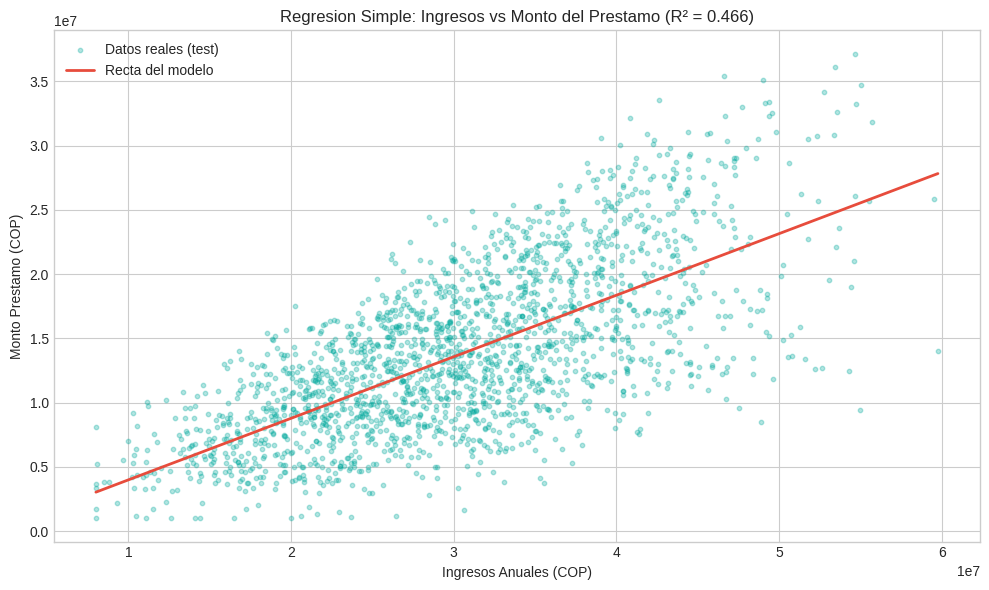

In [ ]:
# Grafico de dispersion con la recta del modelo
plt.figure(figsize=(10, 6))
plt.scatter(X_test, y_test, alpha=0.3, s=10, color='#00A99D', label='Datos reales (test)')
plt.plot(X_test.sort_values('ingresos_anuales'),
         modelo_simple.predict(X_test.sort_values('ingresos_anuales')),
         color='#e74c3c', linewidth=2, label='Recta del modelo')
plt.xlabel('Ingresos Anuales (COP)')
plt.ylabel('Monto Prestamo (COP)')
plt.title(f'Regresion Simple: Ingresos vs Monto del Prestamo (R² = {r2_test:.3f})')
plt.legend()
plt.tight_layout()
plt.show()

---
## Paso 8: Regresion Multiple

In [ ]:
X = df[['edad', 'antiguedad_laboral', 'ingresos_anuales', 'puntaje_credito']]
y = df['monto_prestamo']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

modelo_multiple = LinearRegression()
modelo_multiple.fit(X_train, y_train)

print('--- Regresion Multiple ---')
print(f'Intercepto: ${modelo_multiple.intercept_:,.2f}')
for nombre, coef in zip(X_train.columns, modelo_multiple.coef_):
    print(f'  {nombre}: {coef:.4f}')
print(f'\nR2 entrenamiento: {modelo_multiple.score(X_train, y_train):.3f}')
print(f'R2 prueba:        {modelo_multiple.score(X_test, y_test):.3f}')

--- Regresion Multiple ---
Intercepto: $-1,400,609.27
  edad: 75611.3186
  antiguedad_laboral: -28047.9478
  ingresos_anuales: 0.4287
  puntaje_credito: -910.6140

R2 entrenamiento: 0.478
R2 prueba:        0.467


---
---

# TU TURNO: Predice un Nuevo Cliente

Imagina que llega un nuevo cliente al banco. Tu trabajo es usar el modelo de **regresion multiple** para predecir **cuanto prestamo solicitaria**.

Reemplaza cada `xxx` con un valor realista y ejecuta la celda.

In [ ]:
# ============================================
# TU TURNO: Completa los datos del cliente
# ============================================

mi_cliente = {
    'edad':                25,   # Ejemplo: 35 (rango: 22-65)
    'antiguedad_laboral':  5,   # Ejemplo: 10 (rango: 0-40)
    'ingresos_anuales':    4000000,   # Ejemplo: 40000000 (en COP)
    'puntaje_credito':     849,   # Ejemplo: 620 (rango: 300-850)
}

# --- No modifiques debajo de esta linea ---
cliente_df = pd.DataFrame([mi_cliente])
prediccion_monto = modelo_multiple.predict(cliente_df)[0]

print('========== PREDICCION: MONTO DEL PRESTAMO ==========')
print(f'Edad:                {mi_cliente["edad"]} anos')
print(f'Antiguedad laboral:  {mi_cliente["antiguedad_laboral"]} anos')
print(f'Ingresos anuales:    ${mi_cliente["ingresos_anuales"]:,.0f} COP')
print(f'Puntaje de credito:  {mi_cliente["puntaje_credito"]}')
print(f'\n>>> Monto estimado del prestamo: ${prediccion_monto:,.0f} COP')

========== PREDICCION: MONTO DEL PRESTAMO ==========
Edad:                25 anos
Antiguedad laboral:  5 anos
Ingresos anuales:    $4,000,000 COP
Puntaje de credito:  849

>>> Monto estimado del prestamo: $1,291,284 COP


Conclusion: De acuerdo al estudio realizado nos damos cuenta que a medida que aumenta la edad y decrecen los años de antiguedad, el monto estimado aumenta. Sin embargo esto tambien va ligado al monto de ingresos anuales. Otra observacion es que a medida que aumente el puntaje crediticio el monto se ve que decrece